# slimfarmer tutorial

End-to-end photometry on a Roman IMCOM CPR image.

**Steps**
1. Prepare images from the CPR file (science, weight, PSF)
2. Run slimfarmer
3. Inspect catalog
4. Validate photometry against the truth catalog
5. Diagnose individual sources

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.wcs import WCS
import astropy.units as u
from scipy.stats import binned_statistic
import sys
sys.path.insert(0, "../../")
import slimfarmer
from slimfarmer.track import _get_flux_converters

print(f'slimfarmer {slimfarmer.__version__}')

slimfarmer 1.0.0


## 1. Prepare images from CPR

`prepare_images_from_cpr` reads an IMCOM compressed output file and writes three FITS files:
- **science image** — layer 0 of the CPR cube (background-subtracted DN/px/s)
- **weight map** — inverse-variance, combining correlated reconstruction noise and Poisson noise
- **PSF stamp** — 2-D Gaussian at the Roman H158 effective FWHM, normalised to sum=1

In [2]:
CPR_PATH = '/home/chto/code/Roman/data/openUV24/im3x2-H0_00_00.cpr.fits.gz'
WORK_DIR = '/home/chto/code/Roman/data/openUV24/output_slimfarmer/'

sci_path, wht_path, psf_path = slimfarmer.prepare_images_from_cpr(
    cpr_path = CPR_PATH,
    work_dir = WORK_DIR,
    # psf_fwhm_arcsec=0.240,  # override if needed
)
print(f'sci: {sci_path}')
print(f'wht: {wht_path}')
print(f'psf: {psf_path}')

sci: /home/chto/code/Roman/data/openUV24/output_slimfarmer/roman_image.fits
wht: /home/chto/code/Roman/data/openUV24/output_slimfarmer/roman_weight.fits
psf: /home/chto/code/Roman/data/openUV24/output_slimfarmer/PSF_F158.fits


In [3]:
(0.24/0.049)**2

23.99000416493127

Image shape : (2108, 2108)
Pixel scale : 0.04902 arcsec/px
Science range: -7.548 – 1282.031
Weight range : 1.935e-01 – 6.693e+03


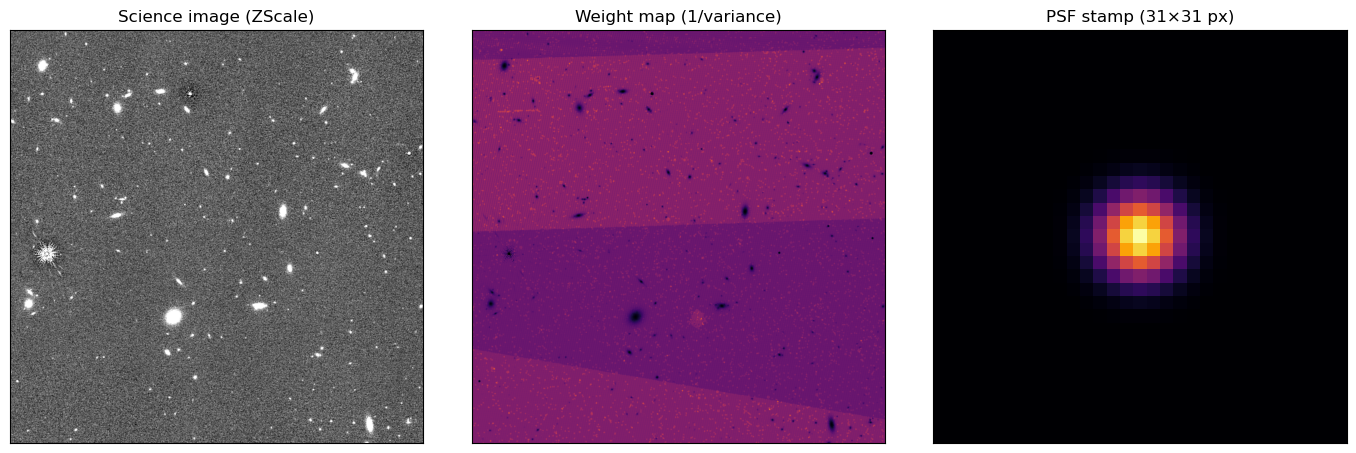

In [4]:
# Preview science image and weight map
sci = fits.getdata(sci_path).astype(float)
wht = fits.getdata(wht_path).astype(float)
psf = fits.getdata(psf_path).astype(float)

with fits.open(sci_path) as h:
    pix_scale = abs(h[0].header['CDELT2']) * 3600.
print(f'Image shape : {sci.shape}')
print(f'Pixel scale : {pix_scale:.5f} arcsec/px')
print(f'Science range: {sci.min():.3f} – {sci.max():.3f}')
print(f'Weight range : {wht.min():.3e} – {wht.max():.3e}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

norm = ImageNormalize(sci, interval=ZScaleInterval())
axes[0].imshow(sci, origin='lower', cmap='gray', norm=norm)
axes[0].set_title('Science image (ZScale)')

axes[1].imshow(wht, origin='lower', cmap='inferno')
axes[1].set_title('Weight map (1/variance)')

axes[2].imshow(psf, origin='lower', cmap='inferno')
axes[2].set_title(f'PSF stamp ({psf.shape[0]}×{psf.shape[1]} px)')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [5]:
np.median(np.sqrt(1/wht))

np.float64(0.020727536295739098)

## 2. Run slimfarmer

In [ ]:
import galsim, galsim.roman as groman

bp        = galsim.roman.getBandpasses()
BAND      = 'F158'
ZEROPOINT = bp['H158'].zeropoint + 2.5 * np.log10(groman.collecting_area)
print(f'Zeropoint: {ZEROPOINT:.6f}')

cat = slimfarmer.run_photometry(
    science_path = sci_path,
    weight_path  = wht_path,
    psf_path     = psf_path,
    band         = BAND,
    zeropoint    = ZEROPOINT,
    output_path  = WORK_DIR + '/catalog.fits',
    ncpus        = 48,   # set >0 on a cluster
    neighbor_subtraction = False,
    
)
print(f'\n{len(cat)} sources detected')

[13:32:38] slimfarmer :: INFO - Loading F158 from /home/chto/code/Roman/data/openUV24/output_slimfarmer/roman_image.fits
[13:32:38] slimfarmer :: INFO - Running SEP source detection...


Zeropoint: 26.511268


[13:32:39] slimfarmer :: INFO - Detected 3023 sources.
[13:32:39] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[13:32:40] slimfarmer :: INFO - Found 2471 groups.
[13:32:40] slimfarmer :: INFO - Processing 2471 groups (ncpus=48)...
Groups:  29%|███████████████████████████████████████████▏                                                                                                        | 721/2471 [01:00<03:23,  8.60it/s]

## 3. Inspect catalog

In [ ]:
# Model type breakdown
from collections import Counter
names = [n.decode() if isinstance(n, bytes) else str(n) for n in cat['name']]
print('Model type counts:')
for model, count in Counter(names).most_common():
    print(f'  {model:30s} {count:4d}')

In [ ]:
# SNR distribution
snr = np.array(cat[f'{BAND}_flux'], dtype=float) / np.array(cat[f'{BAND}_flux_err'], dtype=float)
finite = np.isfinite(snr) & (snr > 0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(snr[finite], bins=60, range=(0, 80), color='steelblue', edgecolor='white', lw=0.4)
ax.axvline(5,  color='orange', ls='--', lw=1.5, label='SNR = 5')
ax.axvline(18, color='red',    ls='--', lw=1.5, label='SNR = 18')
ax.set_xlabel(f'SNR  ({BAND}_flux / {BAND}_flux_err)')
ax.set_ylabel('N sources')
ax.legend()
plt.tight_layout(); plt.show()
print(f'SNR > 5:  {(snr[finite] > 5).sum()}')
print(f'SNR > 18: {(snr[finite] > 18).sum()}')

In [ ]:
# Source positions overlaid on the science image
wcs_img = WCS(fits.getheader(sci_path))
x_all, y_all = wcs_img.world_to_pixel_values(cat['ra'], cat['dec'])
high_snr = snr > 18

norm = ImageNormalize(sci, interval=ZScaleInterval())
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(sci, origin='lower', cmap='gray', norm=norm)
ax.scatter(x_all[high_snr], y_all[high_snr], s=2, c='orange', alpha=0.8, label='SNR ≥ 18')
for i in np.where(high_snr)[0]:
    e = Ellipse(xy=(x_all[i], y_all[i]),
                width=6*float(cat['a'][i]), height=6*float(cat['b'][i]),
                angle=float(cat['theta'][i]) * 180. / np.pi)
    e.set_facecolor('none'); e.set_edgecolor('red'); e.set_linewidth(0.5)
    ax.add_artist(e)
ax.legend(fontsize=9)
ax.set_title(f'Roman {BAND}  —  {sci.shape[1]}×{sci.shape[0]} px')
#plt.xlim(750, 900)
#plt.ylim(570, 750)
print(cat['id'][np.where((x_all>750)&(x_all<900)&(570<y_all)&(y_all<750))])
plt.tight_layout(); plt.show()

## 4. Validate photometry against the truth catalog

In [ ]:
DATA="/project/kicp/chto/Roman/openUV24/"

In [ ]:
truth = (pd.read_parquet(DATA + '/galaxy_flux_10307.parquet')
           .merge(pd.read_parquet(DATA + '/galaxy_10307.parquet'), on='galaxy_id'))

obs_to_nm, truth_to_nm = _get_flux_converters(sci_path, BAND)

cat_c  = SkyCoord(cat['ra'], cat['dec'], unit='deg')
tru_c  = SkyCoord(truth['ra'].values, truth['dec'].values, unit='deg')
idx, d2d, _ = cat_c.match_to_catalog_sky(tru_c)
sep_as = d2d.to(u.arcsec).value

flux_obs  = np.array([obs_to_nm(float(f)) for f in cat[f'{BAND}_flux']])
flux_true = np.array([truth_to_nm(float(truth['roman_flux_H158'].iloc[i])) for i in idx])
src_names = np.array([n.decode() if isinstance(n, bytes) else str(n) for n in cat['name']])

good  = ((sep_as < 0.1) & (snr > 18) & (flux_true > 0)
         & np.isfinite(flux_obs) & (src_names != 'PointSource'))
ratio = flux_obs[good] / flux_true[good]

print(f'Matched {good.sum()} high-quality galaxies (sep<0.2", SNR>18, non-PS)')
print(f'  median ratio : {np.median(ratio):.4f}')
print(f'  16/84 pctile : {np.percentile(ratio,16):.4f} / {np.percentile(ratio,84):.4f}')
print(f'  NMAD         : {1.4826*np.median(np.abs(ratio-np.median(ratio))):.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Flux ratio histogram
axes[0].hist(ratio, bins=40, range=(0.4, 1.8), color='steelblue', edgecolor='white', lw=0.4)
axes[0].axvline(np.median(ratio), color='red',   lw=2,   label=f'median={np.median(ratio):.3f}')
axes[0].axvline(1.0,              color='black', lw=1.5, ls='--', label='ratio=1')
axes[0].set_xlabel('obs / true flux  (nanomaggies)')
axes[0].set_ylabel('N'); axes[0].legend()
axes[0].set_title('Flux ratio')

# Residuals vs magnitude
mag_true = 22.5 - 2.5 * np.log10(flux_true[good] + 1e-30)
resid    = -2.5 * np.log10(ratio) * 1000   # mmag

magbins   = np.linspace(19, 26, 9)
midpoints = 0.5 * (magbins[:-1] + magbins[1:])
med_r, _, _ = binned_statistic(mag_true, resid, bins=magbins, statistic=np.nanmedian)
std_r, _, _ = binned_statistic(mag_true, resid, bins=magbins, statistic=np.nanstd)
cnt_r, _, _ = binned_statistic(mag_true, resid, bins=magbins, statistic='count')

axes[1].axhspan(-32, 32, alpha=0.12, color='green')
axes[1].axhline(0,   color='black', lw=1)
axes[1].axhline(-32, color='green', lw=1, ls='--', label='±32 mmag (3%)')
axes[1].axhline( 32, color='green', lw=1, ls='--')
axes[1].scatter(mag_true, resid, s=3, alpha=0.3, color='steelblue')
axes[1].errorbar(midpoints, med_r,
                 yerr=std_r / np.sqrt(np.maximum(cnt_r, 1)),
                 fmt='o', color='red', capsize=3, label='binned median')
axes[1].set_xlabel('AB mag (truth)'); axes[1].set_ylabel('obs − true [mmag]')
axes[1].set_ylim(-500, 500); axes[1].legend()
axes[1].set_title(f'Flux residuals  (N={good.sum()})')
axes[1].set_ylim(-200,200)
plt.tight_layout(); plt.show()

## 5. Diagnose individual sources

Build a `FarmerImage` once — it can be reused for any number of `diagnose_source` calls.

In [ ]:
with fits.open(sci_path) as h:
    oversamplepix = abs(h[0].header['CDELT2']) * 3600.

img = slimfarmer.FarmerImage(
    bands={BAND: {
        'science':   sci_path,
        'weight':    wht_path,
        'psf':       psf_path,
        'zeropoint': ZEROPOINT,
    }},
    detection_band=BAND,
)
img.detect()
print(f'{len(img.catalog)} sources')

In [ ]:
# Pick a source to inspect — e.g. a bright galaxy with SNR>18
candidates = cat[(snr > 30) & (src_names != 'PointSource')]
print('High-SNR galaxy candidates:')
print(candidates['id', 'F158_mag', 'name', 'total_rchisq'][:10])

In [ ]:
# Diagnose a specific source
SOURCE_ID =96#112#int(candidates['id'][1])   # change to any id

result = slimfarmer.diagnose_source(
    SOURCE_ID, img, truth, obs_to_nm, truth_to_nm, oversamplepix,
    band=BAND, truth_flux_col='roman_flux_H158',
)
plt.show()

In [ ]:
print(f"Model   : {result['model_name']}")
print(f"obs_flux: {result['obs_nm']:.5f} nMgy")
print(f"true_flux: {result['true_nm']:.5f} nMgy")
print(f"obs/true: {result['ratio']:.4f}")
print(f"rchisq  : {result['rchisq']:.4f}")
if not np.isnan(result['reff']):
    print(f"reff    : {result['reff']:.4f} arcsec")

### Track model selection stages for any source

[12:32:56] slimfarmer :: INFO - Loading F158 from /home/chto/code/Roman/data/openUV24/output_slimfarmer/roman_image.fits
[12:32:56] slimfarmer :: INFO - Running SEP source detection...
[12:32:57] slimfarmer :: INFO - Detected 439 sources.
[12:32:57] slimfarmer :: INFO - Grouping with dilation radius 0.14" = 3 px
[12:32:57] slimfarmer :: INFO - Found 399 groups.


Source 96  |  group_id=94  group_pop=1
Position: x=2028.16  y=576.87  ra=10.278852  dec=-43.534738

Truth matches within 10.0":
  galaxy_id=10307201174185  ra=10.278131  dec=-43.534893  sep=1.962"  flux=0.0706 nMgy
  galaxy_id=10307201513256  ra=10.279997  dec=-43.534855  sep=3.018"  flux=0.0010 nMgy
  galaxy_id=10307100962004  ra=10.277506  dec=-43.535663  sep=4.838"  flux=0.0098 nMgy
  galaxy_id=10307101774202  ra=10.280137  dec=-43.535713  sep=4.853"  flux=0.0575 nMgy
  galaxy_id=10307000482235  ra=10.279857  dec=-43.535956  sep=5.109"  flux=0.0724 nMgy
  galaxy_id=10307100857709  ra=10.277285  dec=-43.535602  sep=5.139"  flux=0.0014 nMgy
  galaxy_id=10307100756499  ra=10.276831  dec=-43.534873  sep=5.296"  flux=0.0770 nMgy
  galaxy_id=10307101426369  ra=10.279363  dec=-43.533256  sep=5.501"  flux=0.0354 nMgy
  galaxy_id=10307000676914  ra=10.280210  dec=-43.533445  sep=5.850"  flux=0.0078 nMgy
  galaxy_id=10307100756500  ra=10.276609  dec=-43.534555  sep=5.890"  flux=0.0032 nMgy
  

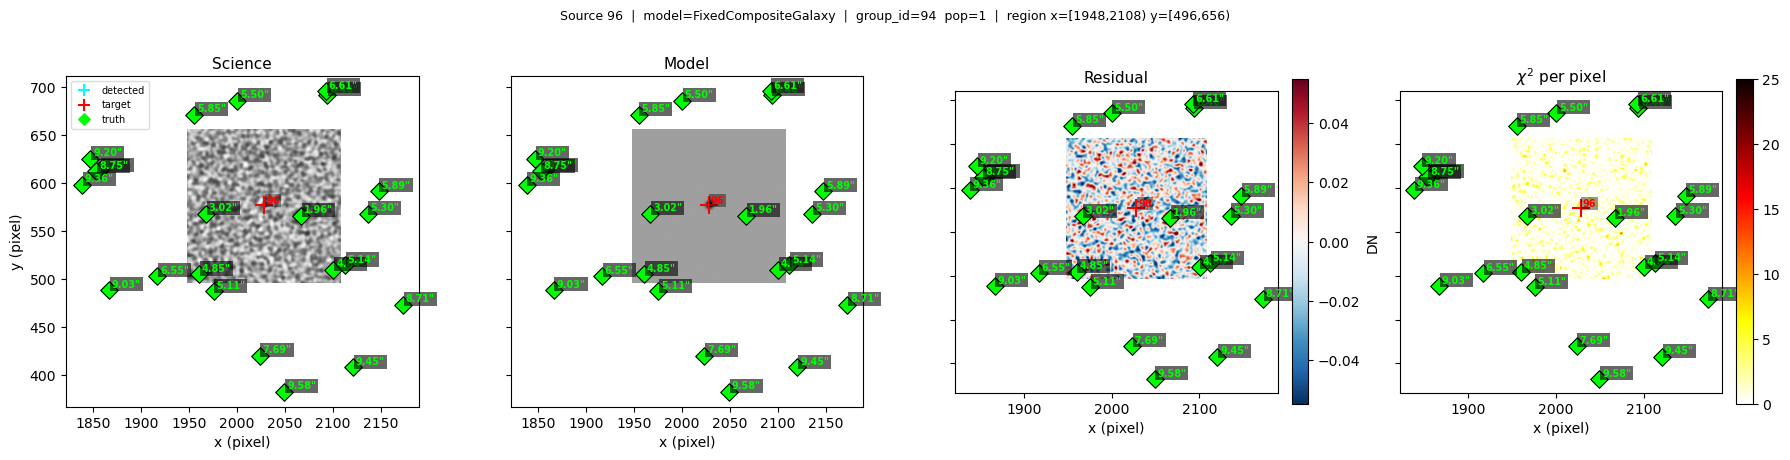

In [41]:
from slimfarmer.track import track_source

result_track = track_source(
    source_id       = SOURCE_ID,
    science_path    = sci_path,
    weight_path     = wht_path,
    psf_path        = psf_path,
    band            = BAND,
    zeropoint       = ZEROPOINT,
    truth_pos_path  = DATA + '/galaxy_10307.parquet',
    truth_flux_path = DATA + '/galaxy_flux_10307.parquet',
    truth_flux_col  = 'roman_flux_H158',
    plot            = True,
)
plt.show()